# Swift EC Policy ML (XGBoost)
Fresh Colab notebook that mirrors the structure of the CatBoost pipeline:
- strict feature allowlist + leaky drop
- group split by workload_id (if present)
- optional log1p target transform
- train 5 XGBoost regressors
- evaluation + feature importance
- **real-row** policy selection evaluation (averaged by (context, policy))
- recommendation on a demo workload JSON


In [ ]:
#@title Install deps
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.3.2
!pip install xgboost==2.0.3



Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 102.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.36.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 5.4 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.1.3
    Uninstalling xgboost-3.1.3:
      Successfully uninstalled xgboost-3.1.3


In [ ]:
#@title Imports & paths
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

BASE = Path(".")  # Colab: /content by default
DATA_RAW = BASE / "data_raw"
DATA_PROC = BASE / "data_processed"
SPLITS = BASE / "data_splits"
MODELS = BASE / "models"
RESULTS = BASE / "results"
PLOTS = RESULTS / "plots"

for d in [DATA_RAW, DATA_PROC, SPLITS, MODELS, RESULTS, PLOTS]:
    d.mkdir(parents=True, exist_ok=True)

print("Dirs ready:", DATA_RAW, DATA_PROC, SPLITS, MODELS, RESULTS)


Dirs ready: data_raw data_processed data_splits models results


## 1) Upload / place your dataset
Put your CSV in `data_raw/dataset.csv` (or change `RAW_CSV`).
Also optionally upload a demo workload JSON (same schema as your friend’s workload_demo.json).

In [ ]:
from pathlib import Path
import pandas as pd

DATASET_PATH = Path("/content/dataset_30k (1).csv")   # upload CSV directly in Colab
assert DATASET_PATH.exists(), "dataset.csv not found. Upload it to Colab root."

df_raw = pd.read_csv(DATASET_PATH)
print("Loaded dataset:", df_raw.shape)


Loaded dataset: (30000, 53)


## 2) Preprocessing (CatBoost-style)
Implements strict allowlist + leaky drop + constant-drop + group split + defaults.json.

In [ ]:
#@title Preprocess + write processed files

WORKLOAD_ID_COL = "workload_id"

TARGETS = [
    "avg_upload_ms","p95_upload_ms","avg_download_ms","p95_download_ms","reconstruction_time_ms"
]

DROP_ALWAYS = ["run_id", "timestamp"]
DROP_REDUNDANT_EC = ["ec_k", "ec_m", "storage_overhead", "efficiency"]

ALLOWED_FEATURES = [
    "policy_name",
    "file_size_mb","num_objects","concurrency","read_ratio","failure_state",

    "total_mb","read_mb","write_mb","per_thread_mb","io_intensity","payload_bytes",

    "data_disks_used_pct_before","mem_available_kb_before","load1_before",
    "cpu_steal_pct_before","runnable_procs","dirty_kb","writeback_kb","swap_activity_delta",

    "disk_reads_delta_max","disk_writes_delta_max","disk_io_time_ms_delta_max",
    "disk_weighted_io_time_delta_max","disk_sectors_rw_delta_max",

    "failed_disks","failed_nodes","failure_disk","time_since_last_failure_s",
]

DROP_LEAKY = [
    "data_disks_used_pct_after","data_disks_used_pct_delta","cpu_util_pct_during_run",
    "net_rx_bytes_delta","net_tx_bytes_delta",
    "total_upload_bytes","total_download_bytes",
    "upload_throughput_mbps","download_throughput_mbps",
    "upload_success_rate","download_success_rate",
]

BASE_CATEGORICALS = ["policy_name", "failure_disk"]

def constant_columns(df: pd.DataFrame, ignore_cols=None):
    ignore_cols = set(ignore_cols or [])
    out = []
    for c in df.columns:
        if c in ignore_cols:
            continue
        if df[c].nunique(dropna=False) <= 1:
            out.append(c)
    return out

df = df_raw.copy()

missing_targets = [t for t in TARGETS if t not in df.columns]
assert not missing_targets, f"Missing targets: {missing_targets}"

drop_cols = set()
for c in DROP_ALWAYS + DROP_REDUNDANT_EC + DROP_LEAKY:
    if c in df.columns:
        drop_cols.add(c)

allowed = [c for c in ALLOWED_FEATURES if c in df.columns]
feature_cols = [c for c in allowed if c not in drop_cols]
assert "policy_name" in feature_cols, "policy_name must be present in feature_cols."

categorical_cols = [c for c in BASE_CATEGORICALS if c in feature_cols]

# drop constant cols except categoricals
const_cols = constant_columns(df[feature_cols], ignore_cols=set(categorical_cols))
feature_cols = [c for c in feature_cols if c not in const_cols]

# keep workload_id as META if present
meta_cols = []
if WORKLOAD_ID_COL in df.columns:
    meta_cols.append(WORKLOAD_ID_COL)

keep_cols = meta_cols + feature_cols + TARGETS
keep_cols = [c for c in keep_cols if c in df.columns]
df_base = df[keep_cols].copy()

# make categoricals strings
for c in categorical_cols:
    if c in df_base.columns:
        df_base[c] = df_base[c].astype(str)

# defaults.json for recommendation-time filling
defaults = {"numeric": {}, "categorical": {}}
for c in feature_cols:
    if c in categorical_cols:
        defaults["categorical"][c] = "NONE"
    else:
        s = pd.to_numeric(df_base[c], errors="coerce")
        med = np.nanmedian(s.to_numpy())
        defaults["numeric"][c] = float(med) if np.isfinite(med) else 0.0

(DATA_PROC / "defaults.json").write_text(json.dumps(defaults, indent=2))

# recon dataset
assert "failure_state" in df_base.columns, "failure_state required."
df_recon = df_base[(df_base["failure_state"] == 1) & (~df_base["reconstruction_time_ms"].isna())].copy()

df_base.to_csv(DATA_PROC / "train_base.csv", index=False)
df_recon.to_csv(DATA_PROC / "train_recon.csv", index=False)

# group split by workload_id if available else fallback context knobs
if WORKLOAD_ID_COL in df.columns:
    groups = df[WORKLOAD_ID_COL].astype(str).iloc[:len(df_base)]
    grouping_used = "workload_id"
else:
    base_group_cols = [c for c in ["file_size_mb","num_objects","concurrency","read_ratio","failure_state"] if c in df.columns]
    groups = df[base_group_cols].astype(str).agg("|".join, axis=1).iloc[:len(df_base)]
    grouping_used = "context"

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx = np.arange(len(df_base))
train_idx, test_idx = next(gss.split(idx, groups=groups))

(SPLITS / "train_idx.txt").write_text("\n".join(map(str, train_idx)))
(SPLITS / "test_idx.txt").write_text("\n".join(map(str, test_idx)))

meta = {
    "rows_raw": int(len(df)),
    "rows_base": int(len(df_base)),
    "rows_recon": int(len(df_recon)),
    "feature_cols": feature_cols,
    "categorical_cols": [c for c in categorical_cols if c in feature_cols],
    "meta_cols": meta_cols,
    "targets": TARGETS,
    "dropped_cols": sorted(list(drop_cols)),
    "dropped_constant_cols": const_cols,
    "split": {"test_size": 0.2, "random_state": 42, "grouping": grouping_used},
}
(DATA_PROC / "metadata.json").write_text(json.dumps(meta, indent=2))

print("[OK] Wrote:", DATA_PROC / "train_base.csv")
print("[OK] Wrote:", DATA_PROC / "train_recon.csv")
print("[OK] Wrote:", DATA_PROC / "metadata.json")
print("[OK] Wrote:", DATA_PROC / "defaults.json")
print("[OK] Wrote splits ->", SPLITS)
print("Features:", len(feature_cols), "Categoricals:", categorical_cols)


[OK] Wrote: data_processed/train_base.csv
[OK] Wrote: data_processed/train_recon.csv
[OK] Wrote: data_processed/metadata.json
[OK] Wrote: data_processed/defaults.json
[OK] Wrote splits -> data_splits
Features: 29 Categoricals: ['policy_name', 'failure_disk']


## 3) Train 5 XGBoost regressors (optional log1p targets)

In [ ]:
#@title Train models (tuned XGBoost + imputers, same core pipeline)

import json
import numpy as np
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

LOG_TARGETS = True  # keep True (usually helps heavy-tailed latency)

meta = json.loads((DATA_PROC / "metadata.json").read_text())
feature_cols = meta["feature_cols"]
categorical_cols = meta["categorical_cols"]
targets = meta["targets"]

df_base = pd.read_csv(DATA_PROC / "train_base.csv")
train_idx = np.array([int(x) for x in (SPLITS / "train_idx.txt").read_text().splitlines() if x.strip()], dtype=int)
test_idx  = np.array([int(x) for x in (SPLITS / "test_idx.txt").read_text().splitlines() if x.strip()], dtype=int)

num_cols = [c for c in feature_cols if c not in categorical_cols]

# ---- Better preprocessing (no functional change; just safer) ----
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

pre = ColumnTransformer(
    transformers=[
        ("cat", cat_pipe, categorical_cols),
        ("num", num_pipe, num_cols),
    ],
    remainder="drop",
)

# ---- Better XGBoost defaults (more robust / less overfit) ----
# You can tweak these slightly later, but these are a strong baseline.
xgb_params = dict(
    n_estimators=4000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2.0,
    gamma=0.0,
    objective="reg:squarederror",
    tree_method="hist",
    max_bin=256,
    random_state=42,
    n_jobs=-1,
)

def safe_log1p(y):
    y = np.asarray(y, dtype=float)
    if np.nanmin(y) < 0:
        raise ValueError("Negative target values found; cannot log1p.")
    return np.log1p(y)

def fit_one(target: str):
    X = df_base[feature_cols].copy()
    y_raw = pd.to_numeric(df_base[target], errors="coerce").to_numpy(dtype=float)

    # reconstruction only valid under failure_state==1
    if target == "reconstruction_time_ms" and "failure_state" in df_base.columns:
        mask = (df_base["failure_state"].astype(float) == 1.0) & (~np.isnan(y_raw))
    else:
        mask = ~np.isnan(y_raw)

    idx_all = np.arange(len(df_base))[mask]
    X = X.iloc[idx_all]
    y_raw = y_raw[mask]

    tr = np.intersect1d(train_idx, idx_all)
    te = np.intersect1d(test_idx, idx_all)

    # map global indices -> local indices
    g2l = {g:i for i,g in enumerate(idx_all)}
    tr_l = np.array([g2l[g] for g in tr], dtype=int)
    te_l = np.array([g2l[g] for g in te], dtype=int)

    if len(tr_l) < 200 or len(te_l) < 100:
        print("[WARN] Not enough rows for", target, "train/test =", len(tr_l), len(te_l))
        return None, None

    y = safe_log1p(y_raw) if LOG_TARGETS else y_raw

    model = XGBRegressor(**xgb_params)
    pipe = Pipeline([("pre", pre), ("model", model)])

    # ensure categorical columns are strings (stable)
    X_fit = X.copy()
    for c in categorical_cols:
        if c in X_fit.columns:
            X_fit[c] = X_fit[c].astype(str)

    pipe.fit(X_fit.iloc[tr_l], y[tr_l])

    pred = pipe.predict(X_fit.iloc[te_l])

    if LOG_TARGETS:
        pred_ms = np.expm1(pred)
        y_te_ms = np.expm1(y[te_l])
    else:
        pred_ms = pred
        y_te_ms = y[te_l]

    mae  = float(mean_absolute_error(y_te_ms, pred_ms))
    rmse = float(np.sqrt(mean_squared_error(y_te_ms, pred_ms)))  # safest RMSE
    r2   = float(r2_score(y_te_ms, pred_ms))

    out = MODELS / f"{target}.joblib"
    joblib.dump(pipe, out)
    return out, {"mae": mae, "rmse": rmse, "r2": r2, "n_eval": int(len(y_te_ms))}

model_info = {
    "xgb_params": xgb_params,
    "target_transform": "log1p" if LOG_TARGETS else "none",
    "features": feature_cols,
    "categoricals": categorical_cols,
    "models": {},
}

rows = []
for t in targets:
    out, m = fit_one(t)
    if out is None:
        continue
    model_info["models"][t] = {"model_file": str(out), "metrics": m}
    rows.append([t, m["mae"], m["rmse"], m["r2"], m["n_eval"]])
    print("[OK]", t, "->", out, m)

(MODELS / "model_info.json").write_text(json.dumps(model_info, indent=2))
metrics_df = pd.DataFrame(rows, columns=["target","MAE_ms","RMSE_ms","R2","n_eval"])
metrics_df


[OK] avg_upload_ms -> models/avg_upload_ms.joblib {'mae': 55.55005152540812, 'rmse': 124.63286400180691, 'r2': 0.3990898752032477, 'n_eval': 6000}
[OK] p95_upload_ms -> models/p95_upload_ms.joblib {'mae': 87.65865666753933, 'rmse': 191.29490321154415, 'r2': 0.36763910308712344, 'n_eval': 6000}
[OK] avg_download_ms -> models/avg_download_ms.joblib {'mae': 22.523166948889624, 'rmse': 52.93148695612282, 'r2': 0.16838409221876138, 'n_eval': 6000}
[OK] p95_download_ms -> models/p95_download_ms.joblib {'mae': 35.197297450377896, 'rmse': 77.26094118029386, 'r2': 0.15904267347822965, 'n_eval': 6000}
[OK] reconstruction_time_ms -> models/reconstruction_time_ms.joblib {'mae': 33.847489361788384, 'rmse': 65.2567839132706, 'r2': 0.5218705825133245, 'n_eval': 2340}


,target,MAE_ms,RMSE_ms,R2,n_eval
0,avg_upload_ms,55.550052,124.632864,0.399090,6000
1,p95_upload_ms,87.658657,191.294903,0.367639,6000
2,avg_download_ms,22.523167,52.931487,0.168384,6000
3,p95_download_ms,35.197297,77.260941,0.159043,6000
4,reconstruction_time_ms,33.847489,65.256784,0.521871,2340


## 4) Evaluate + plots + feature importances

In [ ]:
#@title Evaluate models

model_info = json.loads((MODELS / "model_info.json").read_text())
transform = model_info.get("target_transform", "none")
use_log = (transform == "log1p")

df_base = pd.read_csv(DATA_PROC / "train_base.csv")
test_idx = np.array([int(x) for x in (SPLITS / "test_idx.txt").read_text().splitlines() if x.strip()], dtype=int)
X_test_all = df_base.iloc[test_idx][feature_cols]

table_rows = []
for tgt in targets:
    mp = MODELS / f"{tgt}.joblib"
    if not mp.exists():
        continue

    y_test = df_base.iloc[test_idx][tgt].astype(float)

    if tgt == "reconstruction_time_ms":
        mask = (df_base.iloc[test_idx]["failure_state"] == 1) & (~y_test.isna())
        if mask.sum() < 10:
            table_rows.append([tgt, None, None, None, int(mask.sum()), "not enough recon rows"])
            continue
        X_eval = X_test_all[mask]
        y_eval = y_test[mask].to_numpy(dtype=float)
    else:
        mask = ~y_test.isna()
        X_eval = X_test_all[mask]
        y_eval = y_test[mask].to_numpy(dtype=float)

    pipe = joblib.load(mp)
    pred = pipe.predict(X_eval)
    pred_ms = np.expm1(pred) if use_log else pred

    mae = float(mean_absolute_error(y_eval, pred_ms))
    rmse = float(mean_squared_error(y_eval, pred_ms, squared=False))
    r2 = float(r2_score(y_eval, pred_ms))

    table_rows.append([tgt, mae, rmse, r2, int(len(y_eval)), "ok"])

    plt.figure()
    plt.scatter(y_eval, pred_ms, s=8)
    plt.xlabel("Actual (ms)")
    plt.ylabel("Predicted (ms)")
    plt.title(f"Predicted vs Actual: {tgt} (transform={transform})")
    plt.tight_layout()
    plt.savefig(PLOTS / f"pred_vs_actual_{tgt}.png", dpi=150)
    plt.close()

metrics_df = pd.DataFrame(table_rows, columns=["target","MAE_ms","RMSE_ms","R2","n_eval","notes"])
metrics_df.to_csv(RESULTS / "metrics_table.csv", index=False)
print("[OK] Wrote:", RESULTS / "metrics_table.csv")
print("[OK] Wrote plots ->", PLOTS)
metrics_df


[OK] Wrote: results/metrics_table.csv
[OK] Wrote plots -> results/plots


,target,MAE_ms,RMSE_ms,R2,n_eval,notes
0,avg_upload_ms,55.550052,124.632864,0.399090,6000,ok
1,p95_upload_ms,87.658657,191.294903,0.367639,6000,ok
2,avg_download_ms,22.523167,52.931487,0.168384,6000,ok
3,p95_download_ms,35.197297,77.260941,0.159043,6000,ok
4,reconstruction_time_ms,33.847489,65.256784,0.521871,2340,ok


## 5) Policy selection eval (real-row averaged; Top-1 + Top-K + actual regret)
This is the evaluation approach that usually improves stability versus synthetic-context evaluation.

In [ ]:
#@title Policy selection evaluation

DEFAULT_WEIGHTS = {
    "avg_upload_ms": 1.0,
    "p95_upload_ms": 2.0,
    "avg_download_ms": 1.0,
    "p95_download_ms": 2.0,
    "reconstruction_time_ms": 1.5,
    "storage_overhead": 2.0,
}
TOPK = 3

def parse_ec_km(policy_name: str):
    m = re.match(r"EC-(\d+)-(\d+)", str(policy_name))
    if not m:
        return None, None
    k = int(m.group(1)); p = int(m.group(2))
    return k, p

def overhead_factor(policy_name: str) -> float:
    k, p = parse_ec_km(policy_name)
    if k is None or k == 0:
        return np.nan
    return (k + p) / k  # lower is better

# Normalize overhead into 0..1 across policies used in this evaluation
# (Compute this AFTER you define `policies`)
# OH_MIN, OH_MAX set later.

def norm_overhead(policy_name: str) -> float:
    oh = overhead_factor(policy_name)
    if np.isnan(oh) or OH_MAX == OH_MIN:
        return 0.0
    return (oh - OH_MIN) / (OH_MAX - OH_MIN)

def weighted_score_df(df: pd.DataFrame, weights: dict) -> pd.Series:
    # latency terms
    s = pd.Series(0.0, index=df.index, dtype=float)
    for k, w in weights.items():
        if k == "storage_overhead":
            continue
        if k not in df.columns:
            continue
        x = pd.to_numeric(df[k], errors="coerce").astype(float)
        s = s + float(w) * x.where(~x.isna(), 0.0)

    # overhead term (computed from policy_name)
    w_oh = float(weights.get("storage_overhead", 0.0))
    if w_oh != 0.0 and "policy_name" in df.columns:
        oh_norm = df["policy_name"].astype(str).map(norm_overhead).astype(float)
        s = s + w_oh * oh_norm

    return s.astype(float)

model_info = json.loads((MODELS / "model_info.json").read_text())
transform = model_info.get("target_transform", "none")
use_log = (transform == "log1p")

df_base = pd.read_csv(DATA_PROC / "train_base.csv")
test_idx = np.array([int(x) for x in (SPLITS / "test_idx.txt").read_text().splitlines() if x.strip()], dtype=int)
df_test = df_base.iloc[test_idx].copy()

group_cols = ["workload_id"] if "workload_id" in df_test.columns else [
    c for c in ["file_size_mb","num_objects","concurrency","read_ratio","failure_state"] if c in df_test.columns
]
policies = sorted(df_test["policy_name"].astype(str).unique().tolist())
policy_overheads = [overhead_factor(p) for p in policies]
OH_MIN = float(np.nanmin(policy_overheads))
OH_MAX = float(np.nanmax(policy_overheads))


df_actual = df_test.copy()
if "failure_state" in df_actual.columns:
    df_actual.loc[df_actual["failure_state"] != 1, "reconstruction_time_ms"] = np.nan
df_actual["actual_score_row"] = weighted_score_df(df_actual, DEFAULT_WEIGHTS)

actual_gp = (
    df_actual.groupby(group_cols + ["policy_name"], dropna=False)["actual_score_row"]
    .mean().reset_index().rename(columns={"actual_score_row":"actual_score_mean"})
)

X = df_test[feature_cols].copy()
for c in categorical_cols:
    if c in X.columns:
        X[c] = X[c].astype(str)

df_pred = df_test[group_cols + ["policy_name","failure_state"]].copy()
for tgt in targets:
    pipe = joblib.load(MODELS / f"{tgt}.joblib")
    yhat = pipe.predict(X)
    df_pred[tgt] = np.expm1(yhat) if use_log else yhat

if "failure_state" in df_pred.columns:
    df_pred.loc[df_pred["failure_state"] != 1, "reconstruction_time_ms"] = np.nan
df_pred["pred_score_row"] = weighted_score_df(df_pred, DEFAULT_WEIGHTS)

pred_gp = (
    df_pred.groupby(group_cols + ["policy_name"], dropna=False)["pred_score_row"]
    .mean().reset_index().rename(columns={"pred_score_row":"pred_score_mean"})
)

merged = pd.merge(actual_gp, pred_gp, on=group_cols + ["policy_name"], how="inner")
contexts = merged[group_cols].drop_duplicates()

top1 = topk = total = 0
actual_regrets = []
details = []

for _, ctx_row in contexts.iterrows():
    ctx = ctx_row.to_dict()
    mctx = merged
    for c in group_cols:
        mctx = mctx[mctx[c] == ctx[c]]
    if mctx.empty:
        continue

    true_row = mctx.loc[mctx["actual_score_mean"].idxmin()]
    true_best_policy = str(true_row["policy_name"])
    true_best_actual = float(true_row["actual_score_mean"])

    mctx_sorted = mctx.sort_values("pred_score_mean", ascending=True).reset_index(drop=True)
    pred_best_policy = str(mctx_sorted.loc[0, "policy_name"])
    topk_policies = mctx_sorted["policy_name"].astype(str).head(TOPK).tolist()

    is_top1 = (pred_best_policy == true_best_policy)
    is_topk = (true_best_policy in topk_policies)

    actual_of_pred = float(mctx[mctx["policy_name"] == pred_best_policy]["actual_score_mean"].iloc[0])
    actual_regret = max(0.0, actual_of_pred - true_best_actual)

    top1 += int(is_top1)
    topk += int(is_topk)
    total += 1
    actual_regrets.append(actual_regret)

    details.append({**ctx,
                    "actual_best_policy": true_best_policy,
                    "pred_best_policy": pred_best_policy,
                    "topk": TOPK,
                    "top1_hit": int(is_top1),
                    "topk_hit": int(is_topk),
                    "actual_regret": float(actual_regret),
                    "pred_topk_policies": ",".join(map(str, topk_policies))})

acc1 = top1 / total if total else 0.0
acck = topk / total if total else 0.0
arr = np.array(actual_regrets, dtype=float) if actual_regrets else np.array([0.0], dtype=float)

summary = {
    "n_contexts": int(total),
    "top1_accuracy": float(acc1),
    f"top{TOPK}_accuracy": float(acck),
    "actual_regret_mean": float(np.mean(arr)),
    "actual_regret_median": float(np.median(arr)),
    "actual_regret_p95": float(np.percentile(arr, 95)),
    "transform": transform,
    "group_cols": group_cols,
    "policies_considered": policies,
    "weights": DEFAULT_WEIGHTS,
}

(RESULTS / "policy_selection_summary.json").write_text(json.dumps(summary, indent=2))
pd.DataFrame(details).to_csv(RESULTS / "policy_selection_details.csv", index=False)

print("[OK] Wrote:", RESULTS / "policy_selection_summary.json")
print("[OK] Wrote:", RESULTS / "policy_selection_details.csv")
summary


[OK] Wrote: results/policy_selection_summary.json
[OK] Wrote: results/policy_selection_details.csv


{'n_contexts': 600,
 'top1_accuracy': 0.525,
 'top3_accuracy': 0.8583333333333333,
 'actual_regret_mean': 136.10258390621365,
 'actual_regret_median': 0.0,
 'actual_regret_p95': 578.9723341538967,
 'transform': 'log1p',
 'group_cols': ['workload_id'],
 'policies_considered': ['EC-10-4',
  'EC-2-2',
  'EC-3-2',
  'EC-4-2',
  'EC-4-3',
  'EC-5-3',
  'EC-6-3',
  'EC-7-3',
  'EC-8-3',
  'EC-8-4'],
 'weights': {'avg_upload_ms': 1.0,
  'p95_upload_ms': 2.0,
  'avg_download_ms': 1.0,
  'p95_download_ms': 2.0,
  'reconstruction_time_ms': 1.5,
  'storage_overhead': 2.0}}

## 6) Recommend on a demo workload JSON

In [ ]:
#@title Recommend

import json, numpy as np, pandas as pd, joblib
from pathlib import Path

DATA_PROC = Path("data_processed")
MODELS = Path("models")

# Load metadata + defaults
meta = json.loads((DATA_PROC / "metadata.json").read_text())
feature_cols = meta["feature_cols"]
categorical_cols = meta["categorical_cols"]
targets = meta["targets"]

defaults = json.loads((DATA_PROC / "defaults.json").read_text())
df_base = pd.read_csv(DATA_PROC / "train_base.csv")

WORKLOAD_JSON = Path("workload_demo.json")  # upload to Colab root
assert WORKLOAD_JSON.exists(), f"Upload workload_demo.json to Colab root: {WORKLOAD_JSON}"

wl = json.loads(WORKLOAD_JSON.read_text(encoding="utf-8-sig"))

model_info = json.loads((MODELS/"model_info.json").read_text())
use_log = (model_info.get("target_transform","none") == "log1p")

import re
import numpy as np

# ---- EC overhead helpers ----
def parse_ec_km(policy_name: str):
    m = re.match(r"EC-(\d+)-(\d+)", str(policy_name))
    if not m:
        return None, None
    k = int(m.group(1)); p = int(m.group(2))
    return k, p

def overhead_factor(policy_name: str) -> float:
    k, p = parse_ec_km(policy_name)
    if k is None or k == 0:
        return np.nan
    return (k + p) / k  # lower is better

# ---- weights (now includes overhead) ----
DEFAULT_WEIGHTS = {
    "avg_upload_ms": 1.0,
    "p95_upload_ms": 2.0,
    "avg_download_ms": 1.0,
    "p95_download_ms": 2.0,
    "reconstruction_time_ms": 1.5,
    "storage_overhead": 2.0,   # NEW
}

# ---- normalization values (use medians from df_base) ----
lat_medians = {}
for k in ["avg_upload_ms","p95_upload_ms","avg_download_ms","p95_download_ms","reconstruction_time_ms"]:
    lat_medians[k] = float(np.nanmedian(df_base[k].values)) if k in df_base.columns else 1.0
    if lat_medians[k] == 0 or np.isnan(lat_medians[k]):
        lat_medians[k] = 1.0

# normalize overhead 0..1 across policies
policy_overheads = [overhead_factor(p) for p in policies]
OH_MIN = float(np.nanmin(policy_overheads))
OH_MAX = float(np.nanmax(policy_overheads))

def norm_overhead(policy_name: str) -> float:
    oh = overhead_factor(policy_name)
    if np.isnan(oh) or OH_MAX == OH_MIN:
        return 0.0
    return (oh - OH_MIN) / (OH_MAX - OH_MIN)

def compute_score(pred: dict, weights: dict) -> float:
    s = 0.0

    # latency terms (normalized)
    for k in ["avg_upload_ms","p95_upload_ms","avg_download_ms","p95_download_ms","reconstruction_time_ms"]:
        w = weights.get(k, 0.0)
        v = pred.get(k, None)
        if w == 0.0 or v is None or (isinstance(v, float) and np.isnan(v)):
            continue
        s += float(w) * (float(v) / lat_medians[k])

    # storage overhead term (normalized)
    w_oh = weights.get("storage_overhead", 0.0)
    if w_oh != 0.0:
        pol = pred.get("policy_name", None)
        if pol is not None:
            s += float(w_oh) * float(norm_overhead(pol))

    return float(s)

# Build one row per policy
rows = []
for pol in policies:
    row = dict(wl)
    row["policy_name"] = pol
    rows.append(row)

df_in = pd.DataFrame(rows)

# Ensure all features exist + fill defaults
for c in feature_cols:
    if c not in df_in.columns:
        if c in categorical_cols:
            df_in[c] = defaults["categorical"].get(c, "NONE")
        else:
            df_in[c] = defaults["numeric"].get(c, 0.0)

X = df_in[feature_cols].copy()
for c in feature_cols:
    if c in categorical_cols:
        X[c] = X[c].astype(str).replace({"nan": np.nan}).fillna(defaults["categorical"].get(c, "NONE")).astype(str)
    else:
        X[c] = pd.to_numeric(X[c], errors="coerce").fillna(defaults["numeric"].get(c, 0.0))

# Predict all targets for all policies
preds = {}
for tgt in targets:
    mp = MODELS / f"{tgt}.joblib"
    assert mp.exists(), f"Missing model: {mp}"
    pipe = joblib.load(mp)
    yhat = pipe.predict(X)
    preds[tgt] = (np.expm1(yhat) if use_log else yhat).astype(float)

fs = int(wl.get("failure_state", 0) or 0)

pred_table = []
for i, pol in enumerate(policies):
    pred = {"policy_name": pol}
    for t in targets:
        if t == "reconstruction_time_ms" and fs != 1:
            pred[t] = None
        else:
            pred[t] = float(preds[t][i])
    pred["score"] = compute_score(pred, DEFAULT_WEIGHTS)
    pred_table.append(pred)

pred_df = pd.DataFrame(pred_table).sort_values("score", ascending=True)
display(pred_df.head(10))
print("Recommended:", json.dumps(pred_df.iloc[0].to_dict(), indent=2))


,policy_name,avg_upload_ms,p95_upload_ms,avg_download_ms,p95_download_ms,reconstruction_time_ms,score
0,EC-10-4,500.540222,917.899170,98.156250,157.436188,97.621567,31.085118
7,EC-7-3,504.157471,905.407715,101.489395,159.775269,99.423332,31.447516
5,EC-5-3,530.062378,895.046448,99.195602,155.174042,93.592590,31.447665
4,EC-4-3,523.372742,924.854492,91.994141,149.129456,99.995804,31.707219
8,EC-8-3,528.763367,921.637695,114.114395,157.046021,103.748146,32.074796
2,EC-3-2,498.968323,956.278381,101.011238,148.985062,104.946960,32.093340
9,EC-8-4,516.044006,993.069702,97.188614,161.047760,96.479797,32.403690
1,EC-2-2,514.146118,921.962463,98.794937,150.993179,96.330338,32.664924
6,EC-6-3,554.978027,972.369263,98.772812,172.966553,98.295166,33.458590
3,EC-4-2,511.705811,948.264160,109.140251,174.268555,102.191666,33.559650


Recommended: {
  "policy_name": "EC-10-4",
  "avg_upload_ms": 500.54022216796875,
  "p95_upload_ms": 917.899169921875,
  "avg_download_ms": 98.15625,
  "p95_download_ms": 157.43618774414062,
  "reconstruction_time_ms": 97.62156677246094,
  "score": 31.08511773759279
}


In [ ]:
import re
import numpy as np

def parse_ec_km(policy_name: str):
    # Supports "EC-4-2" etc.
    m = re.match(r"EC-(\d+)-(\d+)", str(policy_name))
    if not m:
        return None, None
    k = int(m.group(1)); p = int(m.group(2))
    return k, p

def overhead_factor(policy_name: str) -> float:
    k, p = parse_ec_km(policy_name)
    if k is None or k == 0:
        return np.nan
    return (k + p) / k  # lower is better

def efficiency(policy_name: str) -> float:
    k, p = parse_ec_km(policy_name)
    if k is None or (k + p) == 0:
        return np.nan
    return k / (k + p)  # higher is better


Using regret column: actual_regret
n=600 | mean=1.8067 | median=0.0898 | p95=11.5576 | max=22.7036


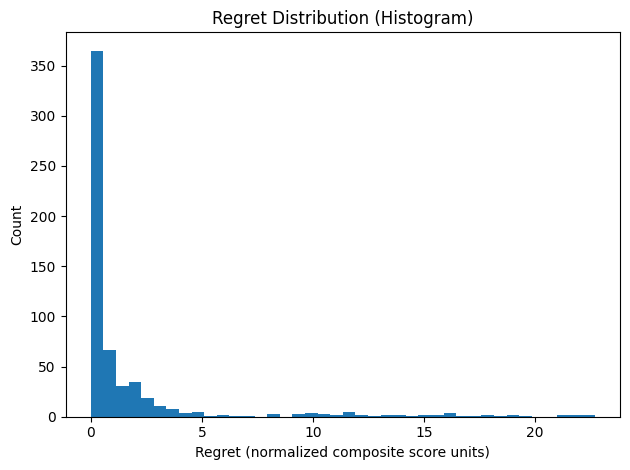

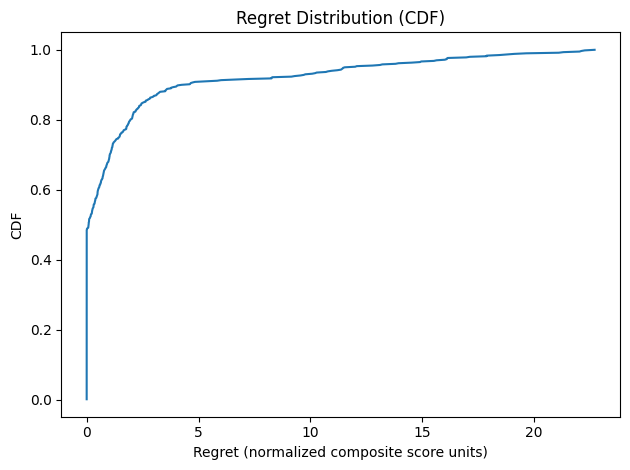

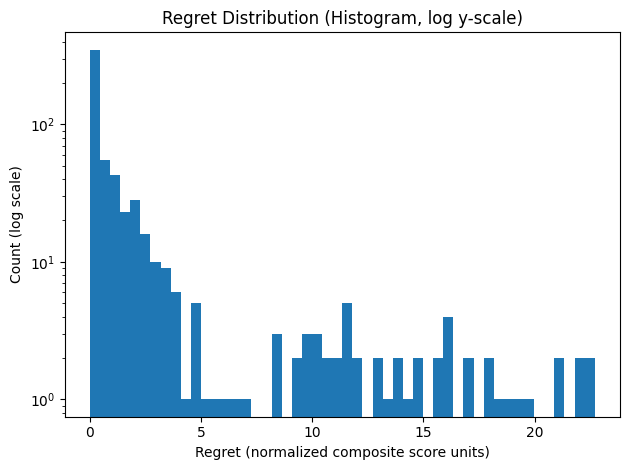

Saved plots to: /content/results/plots


In [ ]:
#@title Regret distribution plots (Histogram + CDF) — UPDATED for normalized/overhead score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT_PLOTS = Path("results/plots")
OUT_PLOTS.mkdir(parents=True, exist_ok=True)

# Load details
try:
    details_df
except NameError:
    details_df = pd.read_csv("results/policy_selection_details.csv")

# Prefer actual_regret (your current eval uses this)
regret_col_candidates = ["actual_regret", "regret", "score_regret", "actual_score_regret"]
regret_col = next((c for c in regret_col_candidates if c in details_df.columns), None)
assert regret_col is not None, f"No regret column found. Available columns: {details_df.columns.tolist()}"

reg = pd.to_numeric(details_df[regret_col], errors="coerce").dropna().astype(float)

# Regret should be non-negative by definition
reg = reg.clip(lower=0.0)

# Decide axis label based on summary flags (if present)
x_label = "Regret (score units)"
summary_path = Path("results/policy_selection_summary.json")
if summary_path.exists():
    try:
        import json
        s = json.loads(summary_path.read_text())
        # If you normalized latencies/overhead, regret is not ms anymore
        if s.get("latency_normalized_by_median", False) or s.get("overhead_normalized_0_1", False):
            x_label = "Regret (normalized composite score units)"
        else:
            x_label = "Regret (weighted-ms score units)"
    except Exception:
        pass

# Summary stats
print(f"Using regret column: {regret_col}")
print(f"n={len(reg)} | mean={reg.mean():.4f} | median={reg.median():.4f} | p95={np.percentile(reg,95):.4f} | max={reg.max():.4f}")

# Histogram
plt.figure()
plt.hist(reg, bins=40)
plt.title("Regret Distribution (Histogram)")
plt.xlabel(x_label)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUT_PLOTS / "regret_hist.png", dpi=200)
plt.show()

# CDF
reg_sorted = np.sort(reg.values)
cdf = np.arange(1, len(reg_sorted) + 1) / len(reg_sorted)

plt.figure()
plt.plot(reg_sorted, cdf)
plt.title("Regret Distribution (CDF)")
plt.xlabel(x_label)
plt.ylabel("CDF")
plt.tight_layout()
plt.savefig(OUT_PLOTS / "regret_cdf.png", dpi=200)
plt.show()

# Optional log-y histogram (helpful if long tail)
plt.figure()
plt.hist(reg, bins=50)
plt.yscale("log")
plt.title("Regret Distribution (Histogram, log y-scale)")
plt.xlabel(x_label)
plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.savefig(OUT_PLOTS / "regret_hist_logy.png", dpi=200)
plt.show()

print("Saved plots to:", OUT_PLOTS.resolve())


In [ ]:
#@title Regret summary (mean / median / p95 / max)

import numpy as np
import pandas as pd

# Load details if not already in memory
try:
    details_df
except NameError:
    details_df = pd.read_csv("results/policy_selection_details.csv")

# Pick the correct regret column (supports different naming)
regret_col_candidates = ["actual_regret", "regret", "score_regret", "actual_score_regret"]
regret_col = next((c for c in regret_col_candidates if c in details_df.columns), None)

assert regret_col is not None, f"No regret column found. Available columns: {details_df.columns.tolist()}"

reg = pd.to_numeric(details_df[regret_col], errors="coerce").dropna().astype(float)

# For regret, clamp negatives (if any) to 0
reg = reg.clip(lower=0.0)

summary = {
    "n_contexts": int(len(reg)),
    "regret_mean": float(np.mean(reg)),
    "regret_median": float(np.median(reg)),
    "regret_p95": float(np.percentile(reg, 95)),
    "regret_max": float(np.max(reg)) if len(reg) else 0.0,
}

print("Regret column:", regret_col)
print(summary)

# Optional: show as a tiny table
pd.DataFrame([summary])


Regret column: actual_regret
{'n_contexts': 600, 'regret_mean': 132.220518682503, 'regret_median': 0.0, 'regret_p95': 566.9483398245844, 'regret_max': 2190.3837806988186}


,n_contexts,regret_mean,regret_median,regret_p95,regret_max
0,600,132.220519,0.0,566.94834,2190.383781


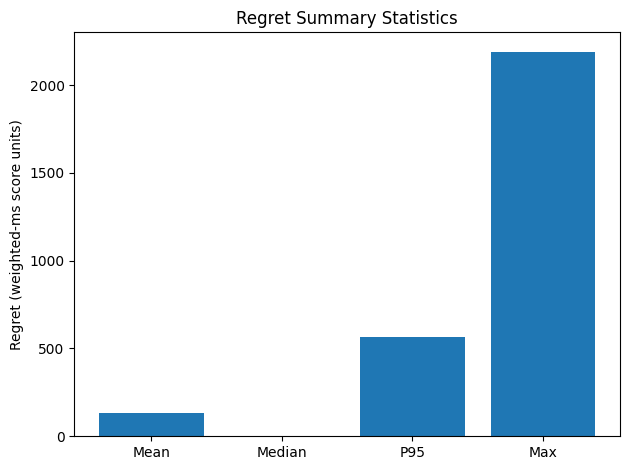

Saved: /content/results/plots/regret_summary_bar.png
{'regret_mean': 132.220518682503, 'regret_median': 0.0, 'regret_p95': 566.9483398245844, 'regret_max': 2190.3837806988186, 'n': 600}


In [ ]:
#@title Regret summary plot (Mean / Median / P95 / Max)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT_PLOTS = Path("results/plots")
OUT_PLOTS.mkdir(parents=True, exist_ok=True)

# Load details if not already in memory
try:
    details_df
except NameError:
    details_df = pd.read_csv("results/policy_selection_details.csv")

# Detect regret column
regret_col_candidates = ["actual_regret", "regret", "score_regret", "actual_score_regret"]
regret_col = next((c for c in regret_col_candidates if c in details_df.columns), None)
assert regret_col is not None, f"No regret column found. Available columns: {details_df.columns.tolist()}"

reg = pd.to_numeric(details_df[regret_col], errors="coerce").dropna().astype(float).clip(lower=0.0)

mean_v = float(np.mean(reg))
median_v = float(np.median(reg))
p95_v = float(np.percentile(reg, 95))
max_v = float(np.max(reg)) if len(reg) else 0.0

labels = ["Mean", "Median", "P95", "Max"]
values = [mean_v, median_v, p95_v, max_v]

# Plot
plt.figure()
plt.bar(labels, values)
plt.title("Regret Summary Statistics")
plt.ylabel("Regret (weighted-ms score units)")
plt.tight_layout()
plt.savefig(OUT_PLOTS / "regret_summary_bar.png", dpi=200)
plt.show()

print("Saved:", (OUT_PLOTS / "regret_summary_bar.png").resolve())
print({"regret_mean": mean_v, "regret_median": median_v, "regret_p95": p95_v, "regret_max": max_v, "n": int(len(reg))})


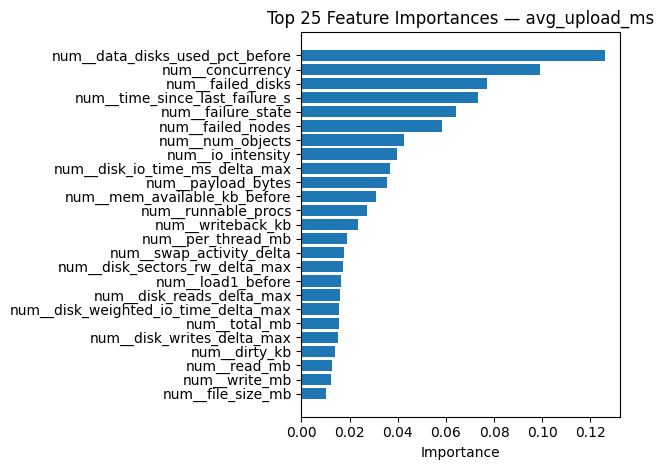

[OK] avg_upload_ms saved: results/feature_importance_avg_upload_ms.csv and results/plots/feature_importance_avg_upload_ms_top25.png


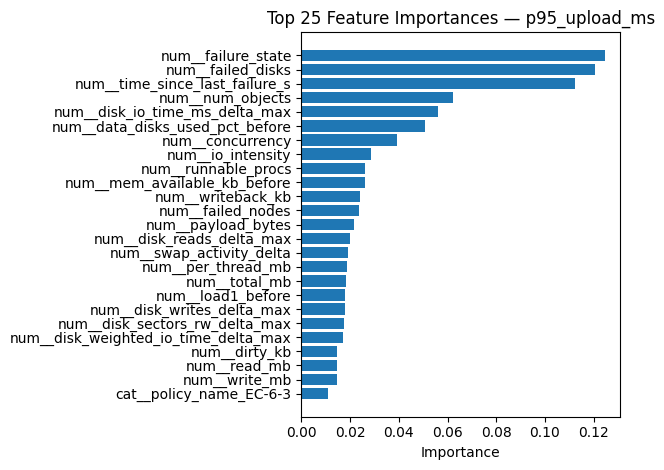

[OK] p95_upload_ms saved: results/feature_importance_p95_upload_ms.csv and results/plots/feature_importance_p95_upload_ms_top25.png


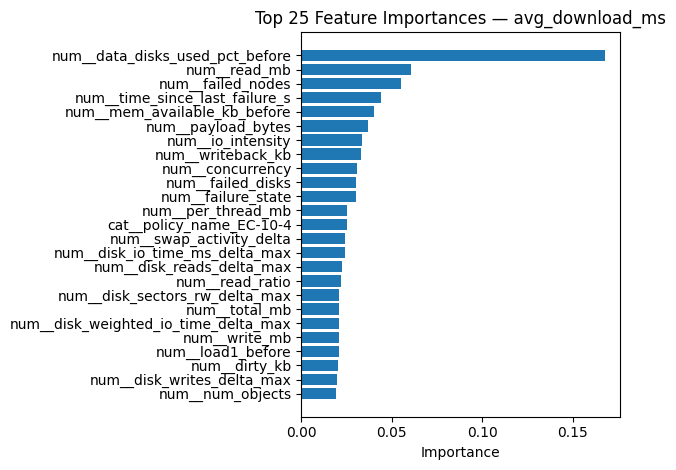

[OK] avg_download_ms saved: results/feature_importance_avg_download_ms.csv and results/plots/feature_importance_avg_download_ms_top25.png


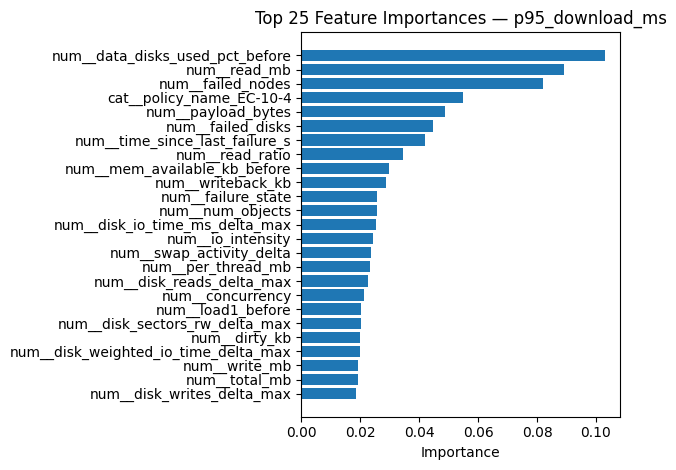

[OK] p95_download_ms saved: results/feature_importance_p95_download_ms.csv and results/plots/feature_importance_p95_download_ms_top25.png


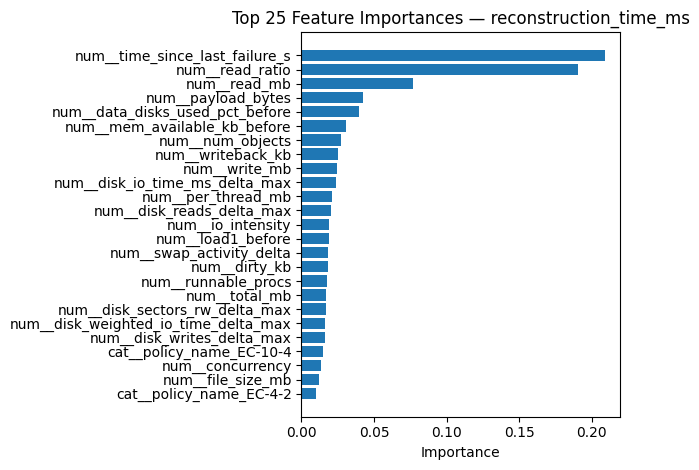

[OK] reconstruction_time_ms saved: results/feature_importance_reconstruction_time_ms.csv and results/plots/feature_importance_reconstruction_time_ms_top25.png


In [ ]:
#@title Feature importance per target (Top-N) + save CSV + bar plot

import json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

MODELS_DIR = Path("models")
RESULTS_DIR = Path("results")
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 25  # change to 10/20/30 if you want

# Load target list from metadata (recommended)
meta_path_candidates = [Path("data_processed/metadata.json"), Path("data/processed/metadata.json")]
meta_path = next((p for p in meta_path_candidates if p.exists()), None)
assert meta_path is not None, "metadata.json not found (expected in data_processed/ or data/processed/)."

meta = json.loads(meta_path.read_text())
targets = meta["targets"]

def get_feature_names_from_preprocessor(pre):
    # Works for ColumnTransformer with OneHotEncoder
    try:
        return pre.get_feature_names_out()
    except Exception:
        # Fallback if get_feature_names_out fails for some sklearn versions
        names = []
        for name, trans, cols in pre.transformers_:
            if name == "remainder" and trans == "drop":
                continue
            if hasattr(trans, "get_feature_names_out"):
                fn = list(trans.get_feature_names_out(cols))
            else:
                fn = list(cols)
            names.extend(fn)
        return np.array(names, dtype=object)

all_importance_tables = {}

for tgt in targets:
    model_path = MODELS_DIR / f"{tgt}.joblib"
    if not model_path.exists():
        print("[SKIP] missing model:", model_path)
        continue

    pipe = joblib.load(model_path)
    pre = pipe.named_steps["pre"]
    model = pipe.named_steps["model"]

    # Get expanded feature names after OneHotEncoder
    feat_names = get_feature_names_from_preprocessor(pre)

    # XGBoost feature importances (gain-based is often better, but sklearn API exposes feature_importances_)
    importances = getattr(model, "feature_importances_", None)
    if importances is None:
        print("[WARN] No feature_importances_ for", tgt)
        continue

    # Align shapes
    if len(importances) != len(feat_names):
        print(f"[WARN] Shape mismatch for {tgt}: names={len(feat_names)} importances={len(importances)}")

    df_imp = pd.DataFrame({
        "feature": feat_names[:len(importances)],
        "importance": importances
    }).sort_values("importance", ascending=False)

    all_importance_tables[tgt] = df_imp

    # Save full table
    out_csv = RESULTS_DIR / f"feature_importance_{tgt}.csv"
    df_imp.to_csv(out_csv, index=False)

    # Plot top-N
    top_df = df_imp.head(TOP_N).iloc[::-1]  # reverse for horizontal bar (small -> big)
    plt.figure()
    plt.barh(top_df["feature"], top_df["importance"])
    plt.title(f"Top {TOP_N} Feature Importances — {tgt}")
    plt.xlabel("Importance")
    plt.tight_layout()
    out_png = PLOTS_DIR / f"feature_importance_{tgt}_top{TOP_N}.png"
    plt.savefig(out_png, dpi=200)
    plt.show()

    print("[OK]", tgt, "saved:", out_csv, "and", out_png)


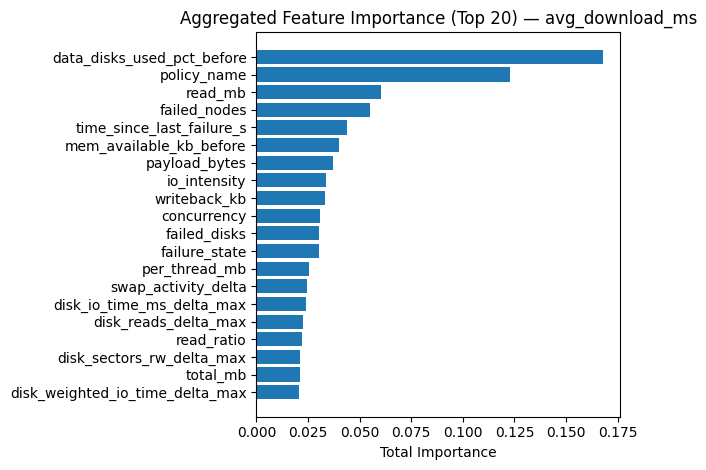

[OK] avg_download_ms aggregated saved: results/feature_importance_avg_download_ms_aggregated.csv and results/plots/feature_importance_avg_download_ms_aggregated_top20.png


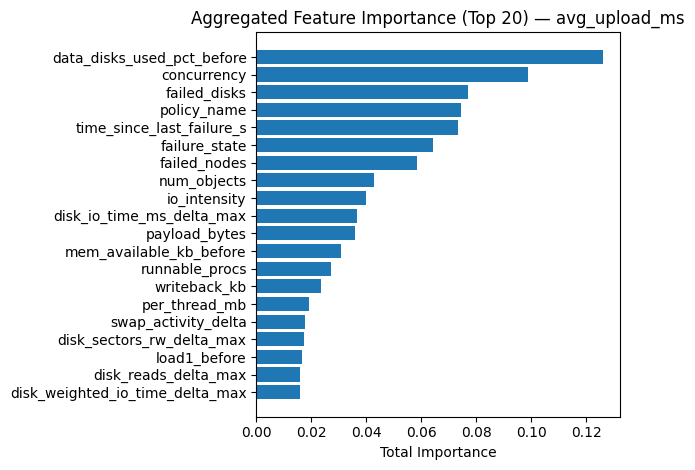

[OK] avg_upload_ms aggregated saved: results/feature_importance_avg_upload_ms_aggregated.csv and results/plots/feature_importance_avg_upload_ms_aggregated_top20.png


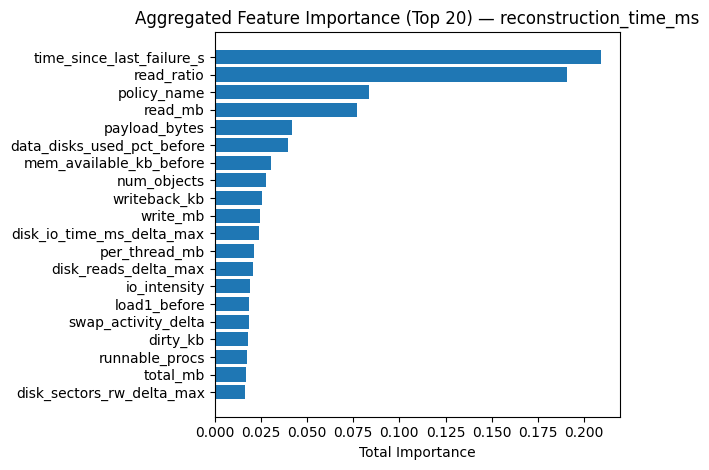

[OK] reconstruction_time_ms aggregated saved: results/feature_importance_reconstruction_time_ms_aggregated.csv and results/plots/feature_importance_reconstruction_time_ms_aggregated_top20.png


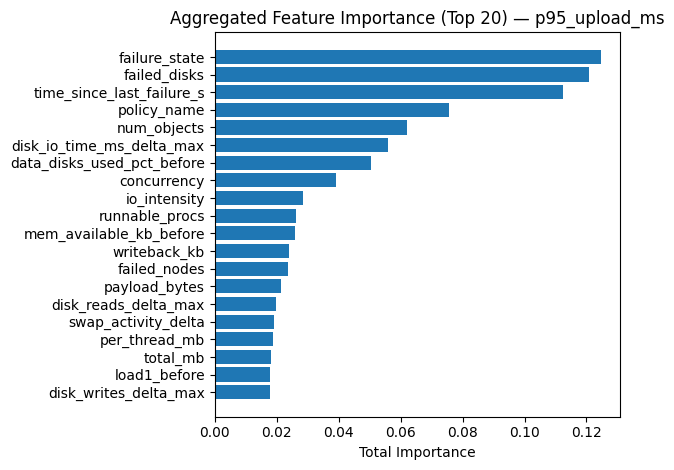

[OK] p95_upload_ms aggregated saved: results/feature_importance_p95_upload_ms_aggregated.csv and results/plots/feature_importance_p95_upload_ms_aggregated_top20.png


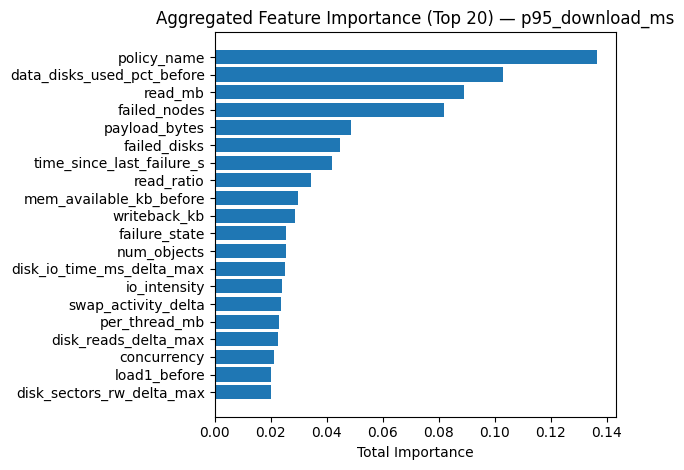

[OK] p95_download_ms aggregated saved: results/feature_importance_p95_download_ms_aggregated.csv and results/plots/feature_importance_p95_download_ms_aggregated_top20.png


In [ ]:
#@title Aggregate one-hot importances back to base feature names (easier for thesis)

import re
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 20

def base_feature(name: str) -> str:
    # Typical OneHotEncoder names look like: cat__policy_name_EC-2-2
    # or: policy_name_EC-2-2
    # We'll collapse to the prefix before the last '_' for categories
    s = str(name)
    s = s.replace("cat__", "").replace("num__", "")
    # Collapse policy_name_* to policy_name, failure_disk_* to failure_disk, etc.
    if "policy_name_" in s:
        return "policy_name"
    if "failure_disk_" in s:
        return "failure_disk"
    # Otherwise keep numeric feature as-is
    return s

for csv_path in RESULTS_DIR.glob("feature_importance_*.csv"):
    tgt = csv_path.name.replace("feature_importance_", "").replace(".csv", "")
    df = pd.read_csv(csv_path)
    df["base_feature"] = df["feature"].map(base_feature)

    agg = df.groupby("base_feature", as_index=False)["importance"].sum().sort_values("importance", ascending=False)

    out_csv = RESULTS_DIR / f"feature_importance_{tgt}_aggregated.csv"
    agg.to_csv(out_csv, index=False)

    top = agg.head(TOP_N).iloc[::-1]
    plt.figure()
    plt.barh(top["base_feature"], top["importance"])
    plt.title(f"Aggregated Feature Importance (Top {TOP_N}) — {tgt}")
    plt.xlabel("Total Importance")
    plt.tight_layout()
    out_png = PLOTS_DIR / f"feature_importance_{tgt}_aggregated_top{TOP_N}.png"
    plt.savefig(out_png, dpi=200)
    plt.show()

    print("[OK]", tgt, "aggregated saved:", out_csv, "and", out_png)


In [ ]:
set(targets).intersection(set(feature_cols))


set()

In [ ]:
#@title Policy selection evaluation (FULL — includes storage overhead + TopK + regret)

import json, re
import numpy as np
import pandas as pd
import joblib

# ----------------------------
# SETTINGS (edit here)
# ----------------------------
TOPK = 3

DEFAULT_WEIGHTS = {
    "avg_upload_ms": 1.0,
    "p95_upload_ms": 2.0,
    "avg_download_ms": 1.0,
    "p95_download_ms": 2.0,
    "reconstruction_time_ms": 1.5,
    "storage_overhead": 2.0,   # NEW: tune this (0.5 / 1.0 / 2.0 etc.)
}

# Normalize latency by median so overhead can actually matter
NORMALIZE_LATENCY_BY_MEDIAN = True
NORMALIZE_OVERHEAD_0_1 = True  # recommended

# ----------------------------
# EC overhead helpers
# ----------------------------
def parse_ec_km(policy_name: str):
    m = re.match(r"EC-(\d+)-(\d+)", str(policy_name))
    if not m:
        return None, None
    k = int(m.group(1)); p = int(m.group(2))
    return k, p

def overhead_factor(policy_name: str) -> float:
    # total stored / original = (k+m)/k  (lower is better)
    k, p = parse_ec_km(policy_name)
    if k is None or k == 0:
        return np.nan
    return (k + p) / k

# ----------------------------
# Load model transform info
# ----------------------------
model_info = json.loads((MODELS / "model_info.json").read_text())
transform = model_info.get("target_transform", "none")
use_log = (transform == "log1p")

# ----------------------------
# Load data
# ----------------------------
df_base = pd.read_csv(DATA_PROC / "train_base.csv")
test_idx = np.array(
    [int(x) for x in (SPLITS / "test_idx.txt").read_text().splitlines() if x.strip()],
    dtype=int
)
df_test = df_base.iloc[test_idx].copy()

# Choose grouping (context) columns
group_cols = ["workload_id"] if "workload_id" in df_test.columns else [
    c for c in ["file_size_mb","num_objects","concurrency","read_ratio","failure_state"] if c in df_test.columns
]
if not group_cols:
    raise ValueError("No suitable group_cols found. Add workload_id or core context columns.")

policies = sorted(df_test["policy_name"].astype(str).unique().tolist())
if not policies:
    raise ValueError("No policies found in df_test['policy_name'].")

# ----------------------------
# Overhead normalization range
# ----------------------------
policy_overheads = [overhead_factor(p) for p in policies]
OH_MIN = float(np.nanmin(policy_overheads))
OH_MAX = float(np.nanmax(policy_overheads))

def norm_overhead(policy_name: str) -> float:
    oh = overhead_factor(policy_name)
    if np.isnan(oh):
        return 0.0
    if not NORMALIZE_OVERHEAD_0_1 or OH_MAX == OH_MIN:
        return float(oh)
    return float((oh - OH_MIN) / (OH_MAX - OH_MIN))  # 0..1

# ----------------------------
# Latency normalization (median)
# ----------------------------
LAT_KEYS = ["avg_upload_ms","p95_upload_ms","avg_download_ms","p95_download_ms","reconstruction_time_ms"]
lat_medians = {}
if NORMALIZE_LATENCY_BY_MEDIAN:
    for k in LAT_KEYS:
        if k in df_base.columns:
            med = float(np.nanmedian(pd.to_numeric(df_base[k], errors="coerce").values))
            if np.isnan(med) or med <= 0:
                med = 1.0
        else:
            med = 1.0
        lat_medians[k] = med
else:
    for k in LAT_KEYS:
        lat_medians[k] = 1.0

# ----------------------------
# Score function (vectorized)
# ----------------------------
def weighted_score_df(df: pd.DataFrame, weights: dict) -> pd.Series:
    s = pd.Series(0.0, index=df.index, dtype=float)

    # latency targets
    for k in LAT_KEYS:
        w = float(weights.get(k, 0.0))
        if w == 0.0 or k not in df.columns:
            continue
        x = pd.to_numeric(df[k], errors="coerce").astype(float)
        x = x.where(~x.isna(), 0.0)
        denom = float(lat_medians.get(k, 1.0)) or 1.0
        s = s + w * (x / denom)

    # overhead
    w_oh = float(weights.get("storage_overhead", 0.0))
    if w_oh != 0.0 and "policy_name" in df.columns:
        oh = df["policy_name"].astype(str).map(norm_overhead).astype(float)
        s = s + w_oh * oh

    return s.astype(float)

# ----------------------------
# Prepare ACTUAL group scores
# ----------------------------
df_actual = df_test.copy()
if "failure_state" in df_actual.columns and "reconstruction_time_ms" in df_actual.columns:
    df_actual.loc[df_actual["failure_state"] != 1, "reconstruction_time_ms"] = np.nan

df_actual["actual_score_row"] = weighted_score_df(df_actual, DEFAULT_WEIGHTS)

actual_gp = (
    df_actual.groupby(group_cols + ["policy_name"], dropna=False)["actual_score_row"]
    .mean()
    .reset_index()
    .rename(columns={"actual_score_row": "actual_score_mean"})
)

# ----------------------------
# Prepare PREDICTED group scores
# ----------------------------
X = df_test[feature_cols].copy()
for c in categorical_cols:
    if c in X.columns:
        X[c] = X[c].astype(str)

df_pred = df_test[group_cols + ["policy_name"]].copy()
if "failure_state" in df_test.columns:
    df_pred["failure_state"] = df_test["failure_state"].values

for tgt in targets:
    pipe = joblib.load(MODELS / f"{tgt}.joblib")
    yhat = pipe.predict(X)
    df_pred[tgt] = np.expm1(yhat) if use_log else yhat

if "failure_state" in df_pred.columns and "reconstruction_time_ms" in df_pred.columns:
    df_pred.loc[df_pred["failure_state"] != 1, "reconstruction_time_ms"] = np.nan

df_pred["pred_score_row"] = weighted_score_df(df_pred, DEFAULT_WEIGHTS)

pred_gp = (
    df_pred.groupby(group_cols + ["policy_name"], dropna=False)["pred_score_row"]
    .mean()
    .reset_index()
    .rename(columns={"pred_score_row": "pred_score_mean"})
)

# ----------------------------
# Merge & evaluate TopK + regret
# ----------------------------
merged = pd.merge(actual_gp, pred_gp, on=group_cols + ["policy_name"], how="inner")
contexts = merged[group_cols].drop_duplicates()

top1 = topk = total = 0
actual_regrets = []
details = []

for _, ctx_row in contexts.iterrows():
    ctx = ctx_row.to_dict()

    mctx = merged
    for c in group_cols:
        mctx = mctx[mctx[c] == ctx[c]]
    if mctx.empty:
        continue

    # True best policy (min actual score)
    true_row = mctx.loc[mctx["actual_score_mean"].idxmin()]
    true_best_policy = str(true_row["policy_name"])
    true_best_actual = float(true_row["actual_score_mean"])

    # Predicted ranking
    mctx_sorted = mctx.sort_values("pred_score_mean", ascending=True).reset_index(drop=True)
    pred_best_policy = str(mctx_sorted.loc[0, "policy_name"])
    topk_policies = mctx_sorted["policy_name"].astype(str).head(TOPK).tolist()

    is_top1 = (pred_best_policy == true_best_policy)
    is_topk = (true_best_policy in topk_policies)

    # Regret computed on ACTUAL score of the predicted-best policy
    actual_of_pred = float(mctx[mctx["policy_name"] == pred_best_policy]["actual_score_mean"].iloc[0])
    actual_regret = max(0.0, actual_of_pred - true_best_actual)

    top1 += int(is_top1)
    topk += int(is_topk)
    total += 1
    actual_regrets.append(actual_regret)

    details.append({
        **ctx,
        "actual_best_policy": true_best_policy,
        "pred_best_policy": pred_best_policy,
        "topk": TOPK,
        "top1_hit": int(is_top1),
        "topk_hit": int(is_topk),
        "actual_best_score": true_best_actual,
        "actual_score_of_pred_best": actual_of_pred,
        "actual_regret": float(actual_regret),
        "pred_topk_policies": ",".join(map(str, topk_policies)),
    })

acc1 = top1 / total if total else 0.0
acck = topk / total if total else 0.0
arr = np.array(actual_regrets, dtype=float) if actual_regrets else np.array([0.0], dtype=float)

summary = {
    "n_contexts": int(total),
    "top1_accuracy": float(acc1),
    f"top{TOPK}_accuracy": float(acck),
    "actual_regret_mean": float(np.mean(arr)),
    "actual_regret_median": float(np.median(arr)),
    "actual_regret_p95": float(np.percentile(arr, 95)),
    "transform": transform,
    "group_cols": group_cols,
    "policies_considered": policies,
    "weights": DEFAULT_WEIGHTS,
    "latency_normalized_by_median": bool(NORMALIZE_LATENCY_BY_MEDIAN),
    "overhead_normalized_0_1": bool(NORMALIZE_OVERHEAD_0_1),
    "overhead_min_factor": OH_MIN,
    "overhead_max_factor": OH_MAX,
}

(RESULTS / "policy_selection_summary.json").write_text(json.dumps(summary, indent=2))
pd.DataFrame(details).to_csv(RESULTS / "policy_selection_details.csv", index=False)

print("[OK] Wrote:", RESULTS / "policy_selection_summary.json")
print("[OK] Wrote:", RESULTS / "policy_selection_details.csv")
summary


[OK] Wrote: results/policy_selection_summary.json
[OK] Wrote: results/policy_selection_details.csv


{'n_contexts': 600,
 'top1_accuracy': 0.4816666666666667,
 'top3_accuracy': 0.7966666666666666,
 'actual_regret_mean': 1.806688463576952,
 'actual_regret_median': 0.0897943529515497,
 'actual_regret_p95': 11.557626856446607,
 'transform': 'log1p',
 'group_cols': ['workload_id'],
 'policies_considered': ['EC-10-4',
  'EC-2-2',
  'EC-3-2',
  'EC-4-2',
  'EC-4-3',
  'EC-5-3',
  'EC-6-3',
  'EC-7-3',
  'EC-8-3',
  'EC-8-4'],
 'weights': {'avg_upload_ms': 1.0,
  'p95_upload_ms': 2.0,
  'avg_download_ms': 1.0,
  'p95_download_ms': 2.0,
  'reconstruction_time_ms': 1.5,
  'storage_overhead': 2.0},
 'latency_normalized_by_median': True,
 'overhead_normalized_0_1': True,
 'overhead_min_factor': 1.375,
 'overhead_max_factor': 2.0}

In [ ]:
try:
    details_df
except NameError:
    details_df = pd.read_csv("results/policy_selection_details.csv")


In [ ]:
#@title Force reload policy selection outputs (sync summary + details)

import json
import numpy as np
import pandas as pd
from pathlib import Path

summary = json.loads(Path("results/policy_selection_summary.json").read_text())
details_df = pd.read_csv("results/policy_selection_details.csv")  # FORCE reload

print("Summary regret_mean:", summary["actual_regret_mean"])
print("Details mean:", float(pd.to_numeric(details_df["actual_regret"], errors="coerce").dropna().mean()))

print("Summary regret_p95:", summary["actual_regret_p95"])
print("Details p95:", float(np.percentile(pd.to_numeric(details_df["actual_regret"], errors="coerce").dropna(), 95)))

print("Top1:", summary["top1_accuracy"], "Top3:", summary["top3_accuracy"])


Summary regret_mean: 1.806688463576952
Details mean: 1.806688463576952
Summary regret_p95: 11.557626856446607
Details p95: 11.557626856446607
Top1: 0.4816666666666667 Top3: 0.7966666666666666


In [ ]:
import json
from pathlib import Path

summary = json.loads(Path("results/policy_selection_summary.json").read_text())
print("Weights:", summary["weights"])
print("Latency normalized by median?:", summary.get("latency_normalized_by_median"))
print("Overhead normalized 0-1?:", summary.get("overhead_normalized_0_1"))
print("Overhead min factor:", summary.get("overhead_min_factor"))
print("Overhead max factor:", summary.get("overhead_max_factor"))


Weights: {'avg_upload_ms': 1.0, 'p95_upload_ms': 2.0, 'avg_download_ms': 1.0, 'p95_download_ms': 2.0, 'reconstruction_time_ms': 1.5, 'storage_overhead': 2.0}
Latency normalized by median?: True
Overhead normalized 0-1?: True
Overhead min factor: 1.375
Overhead max factor: 2.0
